[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/benchuangxd/CSC3109-T16-Project/blob/main/notebooks/03_resnet18.ipynb)

# ResNet-18

**CSC3109 - Machine Learning | Team 16 — Member 2**

In [1]:
# ── Google Colab Setup ──────────────────────────────────────────────────────
# Run this cell first when using Google Colab. No effect when running locally.
import sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    import subprocess
    from pathlib import Path

    REPO_URL  = "https://github.com/benchuangxd/CSC3109-T16-Project.git"
    REPO_PATH = Path("/content/CSC3109-T16-Project")

    if not REPO_PATH.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_PATH)], check=True)
    else:
        print(f"Repo already exists at {REPO_PATH}")

    %cd /content/CSC3109-T16-Project
    %pip install -q -r requirements.txt
    print("Colab setup complete.")
else:
    print("Running locally — skipping Colab setup.")

/content/CSC3109-T16-Project
Colab setup complete.


In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.config import DATA_DIR, CLASS_NAMES, NUM_CLASSES, IMAGE_SIZE, BATCH_SIZE, NUM_EPOCHS, SEED, TRAIN_RATIO
from src.utils import set_seed, get_device

set_seed(SEED)
DEVICE = get_device()
print(f"ROOT   : {ROOT}")
print(f"Device : {DEVICE}")
print(f"Classes: {CLASS_NAMES}")
print(f"Split  : {TRAIN_RATIO:.0%} train / {1-TRAIN_RATIO:.0%} val")
print("Policy : 70/30 split inside each class folder in data/set 16")

ROOT   : /content/CSC3109-T16-Project
Device : cuda
Classes: ['beach', 'ferry_terminal', 'harbor', 'river']
Split  : 70% train / 30% val
Policy : 70/30 split inside each class folder in data/set 16


## 1. Data Loading

The dataloader applies the shared project split: a 70/30 split inside each class folder in `data/set 16`. This keeps every class at 490 train and 210 validation images.


In [3]:
from src.dataset import get_dataloaders

train_loader, val_loader, classes = get_dataloaders(
    root        = ROOT,
    data_dir    = DATA_DIR,
    batch_size  = BATCH_SIZE,
    image_size  = IMAGE_SIZE,
    train_ratio = TRAIN_RATIO,
    seed        = SEED,
    num_workers = 2,
)

def subset_class_counts(subset, class_names):
    targets = subset.dataset.targets
    counts = {cls: 0 for cls in class_names}
    for idx in subset.indices:
        counts[class_names[targets[idx]]] += 1
    return counts

print(f"Classes       : {classes}")
print(f"Split policy  : {TRAIN_RATIO:.0%}/{1-TRAIN_RATIO:.0%} inside each class folder")
print(f"Train batches : {len(train_loader)}  ({len(train_loader.dataset)} images)")
print(f"Val batches   : {len(val_loader)}  ({len(val_loader.dataset)} images)")
print(f"Train counts  : {subset_class_counts(train_loader.dataset, classes)}")
print(f"Val counts    : {subset_class_counts(val_loader.dataset, classes)}")


Classes       : ['beach', 'ferry_terminal', 'harbor', 'river']
Split policy  : 70%/30% inside each class folder
Train batches : 62  (1960 images)
Val batches   : 27  (840 images)
Train counts  : {'beach': 490, 'ferry_terminal': 490, 'harbor': 490, 'river': 490}
Val counts    : {'beach': 210, 'ferry_terminal': 210, 'harbor': 210, 'river': 210}


## 2. Model Setup

ResNet-18 stacks residual blocks with skip connections that let gradients flow through 18 layers without vanishing. ImageNet pretrained model is used, weights and replace only the final fully-connected layer to output 4 classes


In [4]:
from src.models import get_resnet18
from src.utils import count_parameters

model = get_resnet18(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(DEVICE)

total_params = count_parameters(model)
print(f"Trainable parameters : {total_params / 1e6:.2f} M")
print(f"Model head           : {model.fc}")
print(f"Running on           : {DEVICE}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 223MB/s]


Trainable parameters : 11.18 M
Model head           : Linear(in_features=512, out_features=4, bias=True)
Running on           : cuda


## 3. Training the model

ResNet-18 converges quickly on small datasets, so we use **AdamW** (lr=0.0001, weight_decay=0.015) with **ReduceLROnPlateau** to halve the learning rate when val loss stalls. Label smoothing (0.15) keeps predictions from becoming overconfident and early stopping with patience=7 to halt training before the model starts memorising the training set.


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
from pathlib import Path

SAVE_PATH = ROOT / "results" / "saved_models" / "resnet18.pth"
LR        = 1e-4
WD        = 0.015
PATIENCE  = 7

criterion = nn.CrossEntropyLoss(label_smoothing=0.15)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.7, patience=4)


In [6]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == lbls).sum().item()
        total += imgs.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def val_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for imgs, lbls in loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        logits = model(imgs)
        loss = criterion(logits, lbls)

        running_loss += loss.item() * imgs.size(0)
        correct += (logits.argmax(1) == lbls).sum().item()
        total += imgs.size(0)

    return running_loss / total, correct / total


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc, no_improve = 0.0, 0
start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_acc = val_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step(vl_loss)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)

    saved = vl_acc > best_val_acc
    if saved:
        best_val_acc = vl_acc
        no_improve = 0
        SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)
        torch.save(model.state_dict(), SAVE_PATH)
    else:
        no_improve += 1

    lr_now = optimizer.param_groups[0]["lr"]
    tag = " *" if saved else ""
    print(f"[{epoch:02d}/{NUM_EPOCHS}] "
          f"train {tr_loss:.4f} / {tr_acc:.3f}  "
          f"val {vl_loss:.4f} / {vl_acc:.3f}  "
          f"lr {lr_now:.1e}{tag}")

    if no_improve >= PATIENCE:
        print(f"no improvement for {PATIENCE} epochs, stopping")
        break

train_time_min = (time.time() - start_time) / 60
print(f"\nbest val acc : {best_val_acc:.4f}")
print(f"time         : {train_time_min:.1f} min")


[01/20] train 0.6153 / 0.940  val 0.5206 / 0.992  lr 1.0e-04 *
[02/20] train 0.5439 / 0.983  val 0.5143 / 0.996  lr 1.0e-04 *
[03/20] train 0.5192 / 0.990  val 0.5079 / 0.996  lr 1.0e-04
[04/20] train 0.5222 / 0.990  val 0.4982 / 0.999  lr 1.0e-04 *
[05/20] train 0.5215 / 0.986  val 0.4951 / 0.998  lr 1.0e-04
[06/20] train 0.5050 / 0.995  val 0.5066 / 0.988  lr 1.0e-04
[07/20] train 0.5132 / 0.989  val 0.4982 / 1.000  lr 1.0e-04 *
[08/20] train 0.5032 / 0.994  val 0.4881 / 0.999  lr 1.0e-04
[09/20] train 0.5005 / 0.995  val 0.4913 / 0.999  lr 1.0e-04
[10/20] train 0.4983 / 0.995  val 0.4920 / 0.999  lr 1.0e-04
[11/20] train 0.4952 / 0.997  val 0.4905 / 0.995  lr 1.0e-04
[12/20] train 0.4964 / 0.995  val 0.5029 / 0.989  lr 1.0e-04
[13/20] train 0.4951 / 0.996  val 0.4876 / 1.000  lr 1.0e-04
[14/20] train 0.4908 / 0.997  val 0.4841 / 1.000  lr 1.0e-04
no improvement for 7 epochs, stopping

best val acc : 1.0000
time         : 3.1 min


## 4. Training Curves

Loss and accuracy plotted over epochs for both train and val splits.

Training curves saved to /content/CSC3109-T16-Project/results/training_curves/resnet18_training_curve.png


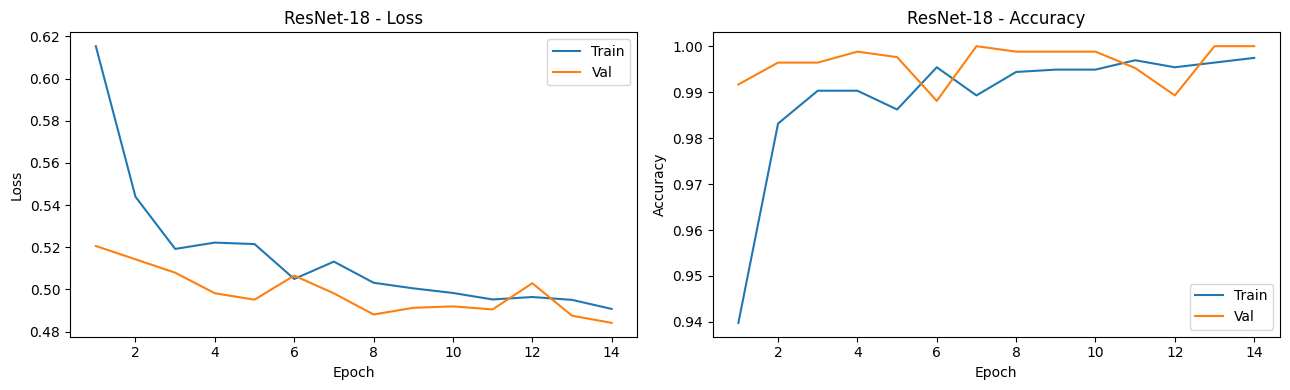

In [7]:
from src.utils import plot_training_curves

CURVES_PATH = ROOT / "results" / "training_curves" / "resnet18_training_curve.png"

plot_training_curves(history, title="ResNet-18", save_path=CURVES_PATH)

## 5. Evaluation

Loads the best checkpoint saved during training and runs inference on the full val set to get the final accuracy, precision, recall, and F1 score.


In [8]:
import torch
from src.evaluate import get_predictions, compute_metrics, print_report

# Load best saved weights before evaluating
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))

y_pred, y_true = get_predictions(model, val_loader, DEVICE)
metrics        = compute_metrics(y_true, y_pred)

print("=" * 40)
print(f"  Accuracy  : {metrics['accuracy']:.4f}")
print(f"  Precision : {metrics['precision']:.4f}")
print(f"  Recall    : {metrics['recall']:.4f}")
print(f"  F1 Score  : {metrics['f1_score']:.4f}")
print("=" * 40)
print()
print_report(y_true, y_pred, CLASS_NAMES)


  Accuracy  : 1.0000
  Precision : 1.0000
  Recall    : 1.0000
  F1 Score  : 1.0000

                precision    recall  f1-score   support

         beach       1.00      1.00      1.00       210
ferry_terminal       1.00      1.00      1.00       210
        harbor       1.00      1.00      1.00       210
         river       1.00      1.00      1.00       210

      accuracy                           1.00       840
     macro avg       1.00      1.00      1.00       840
  weighted avg       1.00      1.00      1.00       840



## 6. Confusion Matrix

Shows which classes the model confuses most often. Off-diagonal entries highlight where misclassifications are concentrated.

Confusion matrix saved to /content/CSC3109-T16-Project/results/confusion_matrices/resnet18_confusion_matrix.png


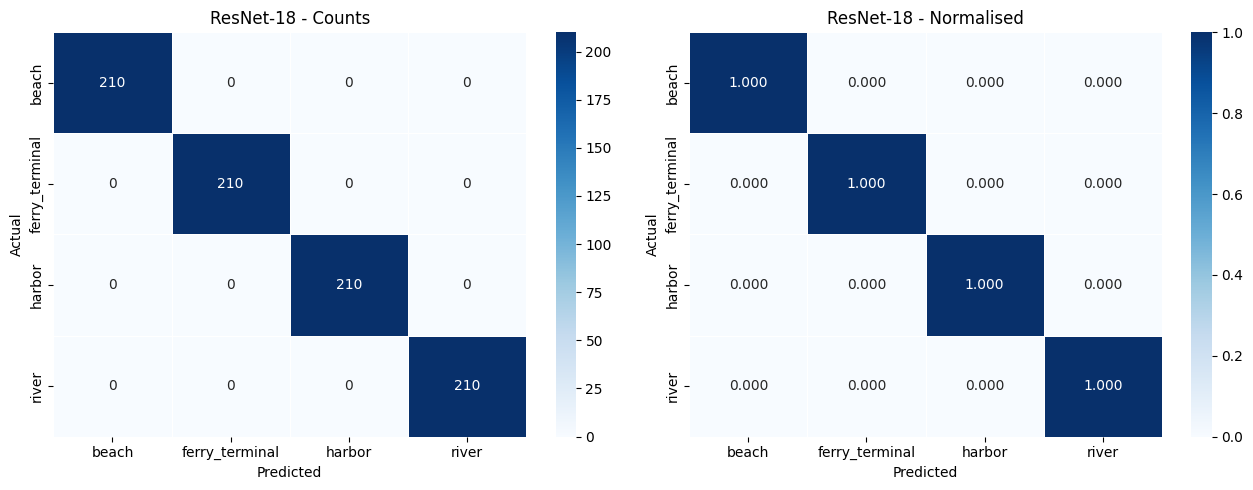

In [9]:
from src.evaluate import plot_confusion_matrix

CM_PATH = ROOT / "results" / "confusion_matrices" / "resnet18_confusion_matrix.png"

plot_confusion_matrix(y_true, y_pred, CLASS_NAMES, title="ResNet-18", save_path=CM_PATH)


## 7. Save Metrics

Writes this model's results to the shared `results/metrics.csv`


In [10]:
from src.utils import save_metrics_to_csv

METRICS_PATH = ROOT / "results" / "metrics.csv"

save_metrics_to_csv("resnet18", metrics, METRICS_PATH)
print("Results written to results/metrics.csv")


Metrics saved to /content/CSC3109-T16-Project/results/metrics.csv
Results written to results/metrics.csv


## 8. Sample Predictions

Randomly samples two images per class from the val set and runs them through the model. Green titles are correct predictions, red are misclassifications.


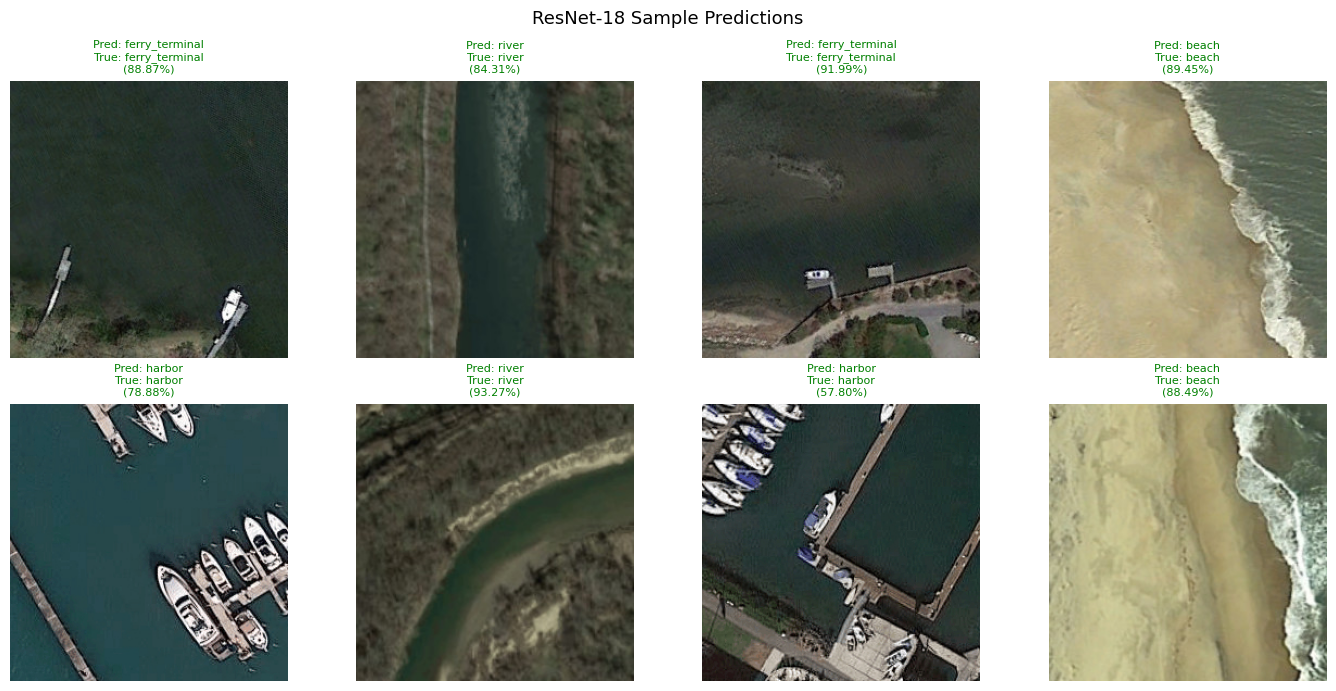

In [11]:
import random
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from src.predict import predict_image

val_subset = val_loader.dataset
val_paths_by_class = {cls: [] for cls in classes}
for idx in val_subset.indices:
    path, target = val_subset.dataset.samples[idx]
    val_paths_by_class[classes[target]].append(Path(path))

sample_paths = []
for cls in classes:
    imgs = val_paths_by_class[cls]
    sample_paths.extend(random.sample(imgs, min(2, len(imgs))))

random.shuffle(sample_paths)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle("ResNet-18 Sample Predictions", fontsize=13)

for ax, path in zip(axes.flat, sample_paths[:8]):
    label, conf, _ = predict_image(path, model, classes, DEVICE, IMAGE_SIZE)
    true_cls = path.parent.name
    img = Image.open(path).convert("RGB")
    ax.imshow(img)
    ax.axis("off")
    color = "green" if label == true_cls else "red"
    title = f"Pred: {label}\nTrue: {true_cls}\n({conf:.2%})"
    ax.set_title(title, fontsize=8, color=color)

plt.tight_layout()
plt.show()
